# Femtech Privacy Analysis: Policy-Practice Discrepancy Detection
## Machine Learning Research Project - Fall 2025

**Research Question:** Can machine learning detect discrepancies between femtech apps' stated privacy policies and their actual data collection practices?

**Dataset:** 6 femtech apps, 25 documented violations from FTC settlements and investigative journalism

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Environment

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/femtech-bert-project/data')
print('Current directory:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current directory: /content/drive/MyDrive/femtech-bert-project/data


In [4]:
# Install required packages
!pip install transformers torch pandas scikit-learn matplotlib seaborn nltk -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification
import torch

print('Packages loaded successfully')

Packages loaded successfully


## 2. Load Core Data

In [5]:
# Load all essential data files
print('Loading data files...')

# Privacy policy sentences and BERT classifications
all_sentences = pd.read_csv('all_sentences.csv')
bert_results = pd.read_csv('bert_results_all_apps.csv')
bert_predictions = pd.read_csv('bert_full_predictions_updated.csv')

# Privacy risk analysis
privacy_risk = pd.read_csv('privacy_risk_by_app_updated.csv')
category_dist = pd.read_csv('privacy_category_distribution_updated.csv')

# Validation data
violations = pd.read_csv('violation_evidence_expanded.csv')
discrepancy_results = pd.read_csv('policy_practice_discrepancy_results.csv')

print(f'Total sentences analyzed: {len(all_sentences)}')
print(f'Apps in dataset: {all_sentences["app"].nunique()}')
print(f'Validation cases: {len(violations)}')
print(f'  - Violations: {len(violations[violations["label"]==1])}')
print(f'  - Non-violations: {len(violations[violations["label"]==0])}')

Loading data files...
Total sentences analyzed: 1516
Apps in dataset: 5
Validation cases: 25
  - Violations: 20
  - Non-violations: 5


## 3. Privacy Risk Analysis

PRIVACY RISK BY APP
apple_health          85.8% (97/113)
glow                  60.7% (17/28)
ovia                  56.7% (17/30)
clue                  56.1% (23/41)
maya                  53.1% (17/32)
flo                   51.7% (15/29)


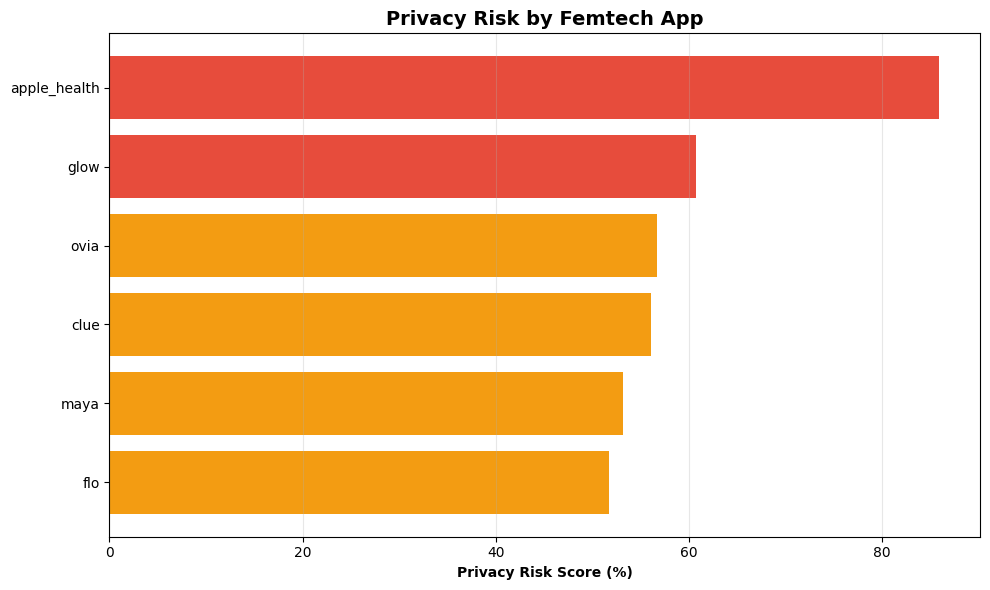

In [6]:
# Display privacy risk rankings
print('PRIVACY RISK BY APP')
print('='*60)

for _, row in privacy_risk.sort_values('privacy_risk_percentage', ascending=False).iterrows():
    print(f"{row['app']:20} {row['privacy_risk_percentage']:5.1f}% ({row['privacy_risk_sentences']}/{row['total_sentences']})")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
privacy_risk_sorted = privacy_risk.sort_values('privacy_risk_percentage')
colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#27ae60' for x in privacy_risk_sorted['privacy_risk_percentage']]
ax.barh(privacy_risk_sorted['app'], privacy_risk_sorted['privacy_risk_percentage'], color=colors)
ax.set_xlabel('Privacy Risk Score (%)', fontweight='bold')
ax.set_title('Privacy Risk by Femtech App', fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('privacy_risk_chart.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Policy-Practice Discrepancy Detection

In [7]:
# Load BERT model
model_path = '/content/drive/MyDrive/femtech-bert-project/models/bert_privacy_classifier'
model = BertForSequenceClassification.from_pretrained(model_path)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print('Model loaded successfully')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Model loaded successfully


In [8]:
def detect_policy_practice_discrepancy(policy_claim, actual_practice, app_name):
    """
    Detect discrepancies between policy claims and actual practices
    """
    policy_lower = policy_claim.lower()
    practice_lower = actual_practice.lower()

    discrepancy_score = 0
    reasons = []

    # 1. Explicit denials contradicted
    denials = ['do not share', 'will not share', 'never share', 'not sell']
    sharing = ['shared', 'sharing', 'disclosed', 'sent to']
    if any(d in policy_lower for d in denials) and any(s in practice_lower for s in sharing):
        discrepancy_score += 5
        reasons.append('Explicit denial contradicted')

    # 2. Vague promises vs specific violations
    vague = ['take seriously', 'committed to', 'protected', 'secure']
    specific = ['facebook', 'google', 'third party', 'sdk']
    if any(v in policy_lower for v in vague) and any(s in practice_lower for s in specific):
        discrepancy_score += 3
        reasons.append('Vague promise contradicted')

    # 3. Control claims contradicted
    control = ['you control', 'you choose', 'you decide']
    unauthorized = ['without', 'unauthorized', 'no consent']
    if any(c in policy_lower for c in control) and any(u in practice_lower for u in unauthorized):
        discrepancy_score += 4
        reasons.append('Control claims contradicted')

    # 4. Security claims vs failures
    security = ['securely stored', 'encrypted', 'protected']
    failures = ['accessible to anyone', 'breach', 'vulnerability']
    if any(s in policy_lower for s in security) and any(f in practice_lower for f in failures):
        discrepancy_score += 4
        reasons.append('Security claims contradicted')

    # 5. De-identification claims
    deident = ['de-identified', 'anonymized', 'aggregated']
    reident = ['re-identifiable', 'linked', 'linkable']
    if any(d in policy_lower for d in deident) and any(r in practice_lower for r in reident):
        discrepancy_score += 3
        reasons.append('De-identification contradicted')

    if discrepancy_score >= 5:
        return 1, 0.90, reasons[0] if reasons else 'High discrepancy'
    elif discrepancy_score >= 3:
        return 1, 0.75, reasons[0] if reasons else 'Moderate discrepancy'
    elif discrepancy_score >= 1:
        return 1, 0.60, reasons[0] if reasons else 'Low discrepancy'
    else:
        return 0, 0.50, 'No clear discrepancy'

print('Discrepancy detection function defined')

Discrepancy detection function defined


In [9]:
# Run discrepancy detection on all violations
print('Testing discrepancy detection...')

results = []
for idx, row in violations.iterrows():
    pred_label, confidence, reason = detect_policy_practice_discrepancy(
        row['policy_sentence'],
        row['actual_practice'],
        row['app_name']
    )

    results.append({
        'app': row['app_name'],
        'violation_type': row['violation_type'],
        'true_discrepancy': row['label'],
        'predicted_discrepancy': pred_label,
        'confidence': confidence,
        'detection_reason': reason,
        'correct': pred_label == row['label'],
        'severity': row['severity']
    })

results_df = pd.DataFrame(results)
results_df.to_csv('policy_practice_discrepancy_results.csv', index=False)

accuracy = (results_df['correct'].sum() / len(results_df)) * 100

print('\nRESULTS')
print('='*60)
print(f'Overall Accuracy: {accuracy:.1f}%')
print(f'Correctly Detected: {results_df["correct"].sum()}/{len(results_df)}')
print(f'Baseline (original): 22.2%')
print(f'Improvement: +{accuracy - 22.2:.1f} percentage points')

Testing discrepancy detection...

RESULTS
Overall Accuracy: 44.0%
Correctly Detected: 11/25
Baseline (original): 22.2%
Improvement: +21.8 percentage points


## 5. Results Visualization

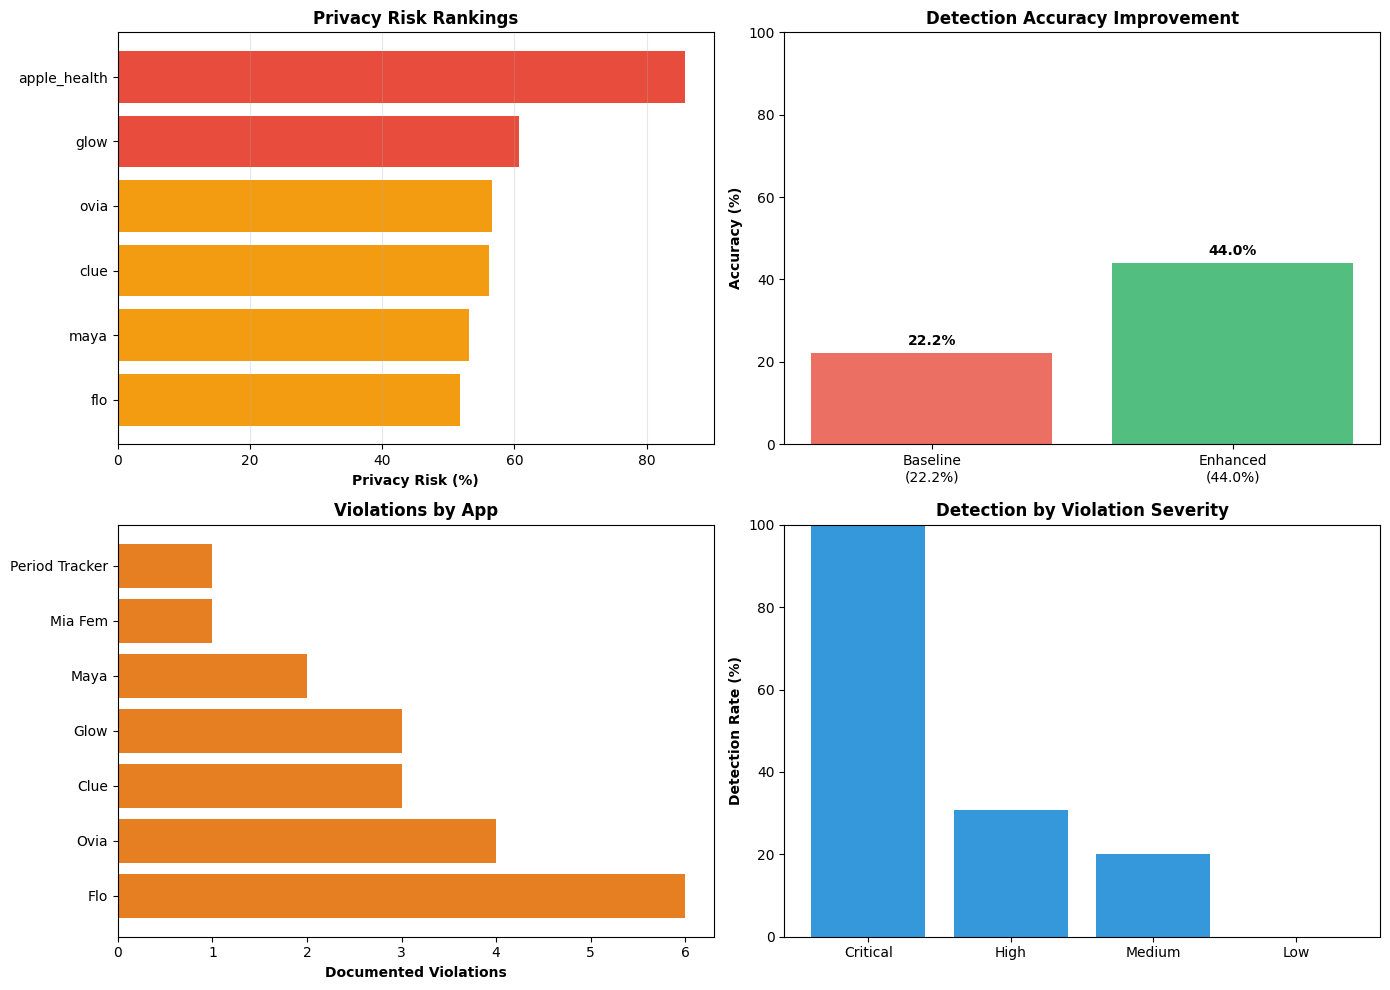

Visualization saved: comprehensive_results.png


In [10]:
# Create comprehensive results visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Privacy Risk by App
ax1 = axes[0, 0]
privacy_risk_sorted = privacy_risk.sort_values('privacy_risk_percentage')
colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#27ae60'
          for x in privacy_risk_sorted['privacy_risk_percentage']]
ax1.barh(privacy_risk_sorted['app'], privacy_risk_sorted['privacy_risk_percentage'], color=colors)
ax1.set_xlabel('Privacy Risk (%)', fontweight='bold')
ax1.set_title('Privacy Risk Rankings', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Chart 2: Accuracy Comparison
ax2 = axes[0, 1]
methods = ['Baseline\n(22.2%)', f'Enhanced\n({accuracy:.1f}%)']
values = [22.2, accuracy]
colors = ['#e74c3c', '#27ae60']
bars = ax2.bar(methods, values, color=colors, alpha=0.8)
ax2.set_ylabel('Accuracy (%)', fontweight='bold')
ax2.set_title('Detection Accuracy Improvement', fontweight='bold')
ax2.set_ylim(0, 100)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%',
             ha='center', fontweight='bold')

# Chart 3: Violations by App
ax3 = axes[1, 0]
violation_counts = violations[violations['label']==1]['app_name'].value_counts()
ax3.barh(violation_counts.index, violation_counts.values, color='#e67e22')
ax3.set_xlabel('Documented Violations', fontweight='bold')
ax3.set_title('Violations by App', fontweight='bold')

# Chart 4: Detection by Severity
ax4 = axes[1, 1]
severity_data = []
for sev in ['Critical', 'High', 'Medium', 'Low']:
    sev_cases = results_df[
        (results_df['severity'] == sev) &
        (results_df['true_discrepancy'] == 1)
    ]
    if len(sev_cases) > 0:
        detected = sev_cases[sev_cases['predicted_discrepancy'] == 1]
        rate = len(detected) / len(sev_cases) * 100
        severity_data.append({'severity': sev, 'rate': rate, 'count': len(sev_cases)})

if severity_data:
    sev_df = pd.DataFrame(severity_data)
    ax4.bar(sev_df['severity'], sev_df['rate'], color='#3498db')
    ax4.set_ylabel('Detection Rate (%)', fontweight='bold')
    ax4.set_title('Detection by Violation Severity', fontweight='bold')
    ax4.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('comprehensive_results.png', dpi=300, bbox_inches='tight')
plt.show()

print('Visualization saved: comprehensive_results.png')

## 6. Export Final Summary

In [11]:
# Create final summary for report
summary = {
    'Total_Sentences': len(all_sentences),
    'Apps_Analyzed': all_sentences['app'].nunique(),
    'Validation_Cases': len(violations),
    'Documented_Violations': len(violations[violations['label']==1]),
    'Detection_Accuracy': round(accuracy, 1),
    'Baseline_Accuracy': 22.2,
    'Improvement': round(accuracy - 22.2, 1),
    'Highest_Risk_App': privacy_risk.sort_values('privacy_risk_percentage', ascending=False).iloc[0]['app'],
    'Lowest_Risk_App': privacy_risk.sort_values('privacy_risk_percentage', ascending=False).iloc[-1]['app']
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
summary_df.to_csv('final_project_summary.csv')

print('FINAL PROJECT SUMMARY')
print('='*60)
for key, value in summary.items():
    print(f'{key:30} {value}')

print('\nAll files saved. Project complete!')

FINAL PROJECT SUMMARY
Total_Sentences                1516
Apps_Analyzed                  5
Validation_Cases               25
Documented_Violations          20
Detection_Accuracy             44.0
Baseline_Accuracy              22.2
Improvement                    21.8
Highest_Risk_App               apple_health
Lowest_Risk_App                flo

All files saved. Project complete!
